In [1]:
import sys
from pathlib import Path


def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "sim_data").exists() and (candidate / "util").exists():
            return candidate
    return current


ROOT_DIR = find_project_root()
sys.path.append(str(ROOT_DIR))

import numpy as np
import ipywidgets as widgets
import matplotlib.pyplot as plt


from math import ceil
from IPython.display import display

from hesel_scraper.bout_dump import BOUTHESELInfo
from hesel_scraper.bout_phys import BOUTHESELPhys


root = ROOT_DIR / 'sim_data/data_15_512_Alexander_'
info = BOUTHESELInfo(root)
phys = BOUTHESELPhys(info)

In [2]:
for (section, name), value in info.settings.items():
    print(f'{section},{name} = {value}')

# for field, value in info.data.__dict__.items():
#     print(f'{field} = {value.shape}')

# for field, value in info.parameters.__dict__.items():
#     print(f'{field} = {value}')

# for name, foo in info.functions.__dict__.items():
#     print(f'{name} = {foo}')

root,datadir = data2
root,mxg = 1
root,myg = 0
root,nout = 1000
root,optionfile = BOUT.inp
root,settingsfile = BOUT.settings
root,t_end = 15000
root,timestep = 15
all,bndry_all = neumann
all,scale = 0.0
fast_output,flushfrequency = 100
fast_output,type = monitor
fast_output,xpos0 = 0.2
fast_output,xpos1 = 0.3
fast_output,xpos2 = 0.4
fast_output,xpos3 = 0.5
fast_output,xpos4 = 0.6
fast_output,xpos5 = 0.7
fast_output,xpos6 = 0.8
fast_output,ypos0 = 0
fast_output,ypos1 = 0
fast_output,ypos2 = 0
fast_output,ypos3 = 0
fast_output,ypos4 = 0
fast_output,ypos5 = 0
fast_output,ypos6 = 0
fast_output,zpos0 = 0.5
fast_output,zpos1 = 0.5
fast_output,zpos2 = 0.5
fast_output,zpos3 = 0.5
fast_output,zpos4 = 0.5
fast_output,zpos5 = 0.5
fast_output,zpos6 = 0.5
hesel,a = 2
hesel,b0 = 1.71
hesel,bracket_method = 2
hesel,bt = 2.28
hesel,collisional_model = 2
hesel,cs = 61313.685044344245
hesel,d_force = 2
hesel,d_lcfs = 2
hesel,d_wall = 2
hesel,diffusion_coeff = 1
hesel,e = 1.6e-19
hesel,edge_width = 56.0


In [4]:
info.settings["root", "t_end"]

15000

In [ ]:
# for (section, name), value in info.settings.items():
#     print(f'{section},{name} = {value}')

# for field, value in info.data.__dict__.items():
#     print(f'{field} = {value.shape}')

# for field, value in info.parameters.__dict__.items():
#     print(f'{field} = {value}')

# for name, foo in info.functions.__dict__.items():
#     print(f'{name} = {foo}')

3D fields: ['lnn', 'lnpe', 'lnpi', 'phi', 'vort']
2D fields: ['init_n', 'init_pe', 'init_pi', 'sigma_open', 'sigma_closed', 'sigma_force', 'B', 'dx', 'lconn']
Skipped scalar fields: ['dz', 'Bt', 'q', 'Te0', 'Ti0', 'n0', 'Rmajor', 'Rminor', 'A', 'Z', 'Mach', 'x_lcfs', 'x_wall', 'force_time', 'floor_time', 'floor_n', 'floor_pe', 'floor_pi', 'B0', 'oci', 'rhoe', 'rhos', 'nuei', 'nuii', 'nuee', 'neoclass_correction_factor', 'lblob']


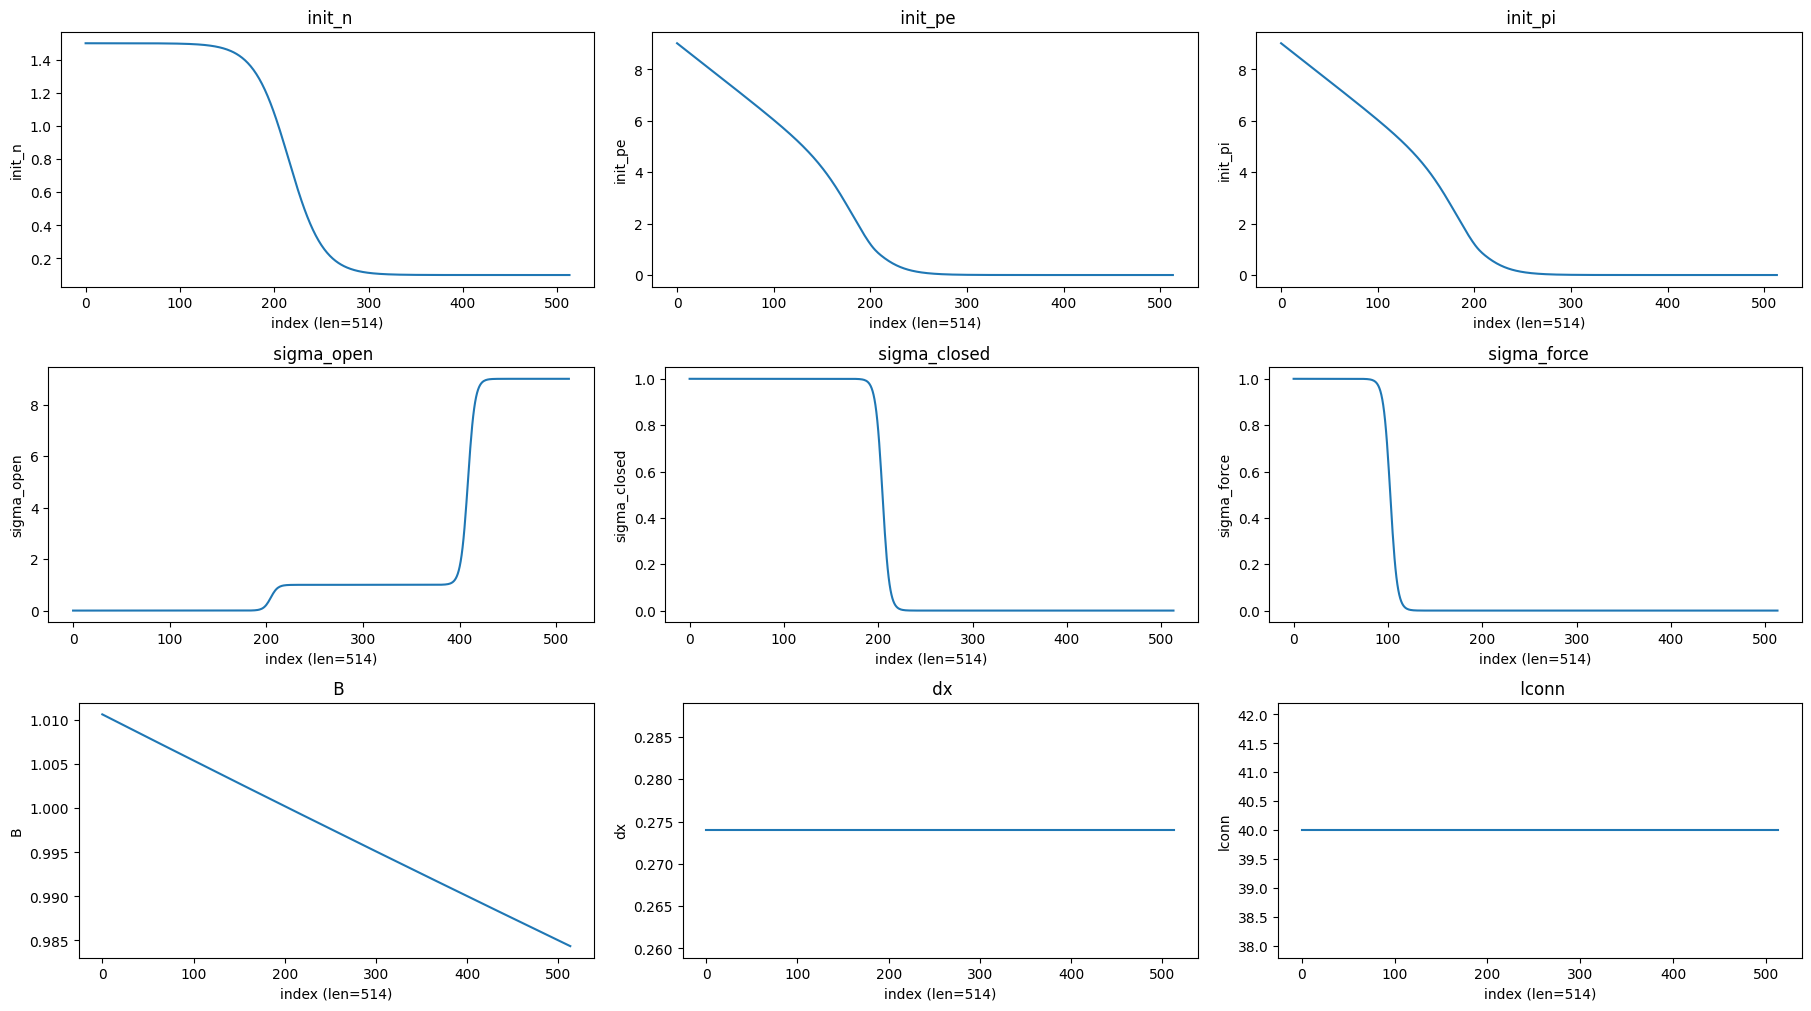

In [3]:
three_d_fields = []
two_d_fields = []
scalar_fields = []
time_array = info.data.t_array.detach().cpu().numpy()
for name, arr in info.data.__dict__.items():
    if arr is None or name == 't_array':
        continue
    if arr.ndim == 3:
        three_d_fields.append((name, arr))
    elif arr.ndim == 1:
        two_d_fields.append((name, arr))
    elif arr.ndim == 0:
        scalar_fields.append(name)

print('3D fields:', [name for name, _ in three_d_fields])
print('2D fields:', [name for name, _ in two_d_fields])
print('Skipped scalar fields:', scalar_fields)

def make_grid(n_items, ncols):
    return ceil(n_items / ncols), ncols

def axis_label(name, length):
    return f'{name} (len={length})'

def plot_3d_frame(time_index):
    time_value = float(time_array[time_index])
    fig = plt.figure(figsize=(18, 10), constrained_layout=True)
    nrows, ncols = make_grid(len(three_d_fields), 3)
    subfigs = np.asarray(fig.subfigures(nrows, ncols, squeeze=False)).ravel()

    for slot, (name, arr) in enumerate(three_d_fields):
        subfig = subfigs[slot]
        ax = subfig.subplots()
        frame = arr[time_index].detach().cpu().numpy().T
        im = ax.imshow(frame, cmap='viridis', interpolation='nearest', vmin=float(arr.min().item()), vmax=float(arr.max().item()))
        ax.set_title(f'{name} @ t={time_value:.4g}')
        ax.set_xlabel(axis_label('x', arr.shape[1]))
        ax.set_ylabel(axis_label('z', arr.shape[2]))
        fig.colorbar(im, ax=ax, shrink=0.8)

    for subfig in subfigs[len(three_d_fields):]:
        subfig.set_visible(False)

    return fig

def plot_two_d_fields():
    fig = plt.figure(figsize=(18, 10), constrained_layout=True)
    nrows, ncols = make_grid(len(two_d_fields), 3)
    subfigs = np.asarray(fig.subfigures(nrows, ncols, squeeze=False)).ravel()

    for slot, (name, arr) in enumerate(two_d_fields):
        subfig = subfigs[slot]
        ax = subfig.subplots()
        values = arr.detach().cpu().numpy()
        ax.plot(np.arange(values.shape[0]), values, linewidth=1.5)
        ax.set_title(f" {name}")
        ax.set_xlabel(axis_label('index', values.shape[0]))
        ax.set_ylabel(name)

    for subfig in subfigs[len(two_d_fields):]:
        subfig.set_visible(False)

    return fig


output_3d = widgets.Output()
slider = widgets.IntSlider(
    min=0,
    max=len(time_array) - 1,
    step=1,
    value=0,
    description='t',
    continuous_update=False,
)

def render_3d(_change=None):
    _ = _change
    with output_3d:
        output_3d.clear_output(wait=True)
        fig = plot_3d_frame(slider.value)
        display(fig)
        plt.close(fig)

slider.observe(render_3d, names='value')
render_3d()
display(widgets.VBox([slider, output_3d]))

fig = None
if two_d_fields:
    fig = plot_two_d_fields()
    display(fig)
if fig is not None:
    plt.close(fig)

In [4]:
# # Load trained PINN from latest checkpoint and render 4x4 comparison with time slider
# import torch
# from pathlib import Path
# import torch.nn.functional as F
# import matplotlib.pyplot as plt
# import ipywidgets as widgets
# from IPython.display import display

# from util.model import PINN
# from util.structure import NN_STRUCTURE

# field_names = ['lnn', 'lnpe', 'lnpi', 'phi']
# column_names = ['Target', 'Predicted', 'Absolute error', 'eq_loss']
# eq_key_for_field = {'lnn': 'eq_lnn', 'lnpe': 'eq_lnpe', 'lnpi': 'eq_lnpi', 'phi': 'eq_vort'}


# def latest_checkpoint() -> Path:
#     search_roots = [Path.cwd() / 'wandb' / 'latest-run', Path.cwd() / 'wandb', Path.cwd() / 'data']
#     checkpoints = sorted({p for root in search_roots if root.exists() for p in root.rglob('*.pt')})
#     if not checkpoints:
#         raise FileNotFoundError('No .pt checkpoint found in wandb/latest-run, wandb, or data.')
#     return checkpoints[-1]


# ckpt = torch.load(latest_checkpoint(), map_location='cpu')
# model = PINN(NN_STRUCTURE)
# state_dict = ckpt['model_state_dict'] if isinstance(ckpt, dict) and 'model_state_dict' in ckpt else ckpt
# model.load_state_dict(state_dict)
# model.eval()

# if isinstance(ckpt, dict) and 'output_scaling' in ckpt:
#     scaling = ckpt['output_scaling']
#     means = torch.tensor([scaling[name]['mean'] for name in field_names], dtype=torch.float32)
#     stds = torch.tensor([scaling[name]['std'] for name in field_names], dtype=torch.float32)
#     standardization = type(info.standardized)(mean=means, std=stds)
# else:
#     standardization = type(info.standardized)(mean=info.standardized.mean, std=info.standardized.std)

# nt, _, _ = info.data.lnn.shape
# fields = {name: torch.as_tensor(getattr(info.data, name), dtype=torch.float32) for name in field_names}
# padded = {name: F.pad(arr, (1, 1, 1, 1), mode='replicate') for name, arr in fields.items()}

# num_x = padded[field_names[0]].shape[1]
# num_z = padded[field_names[0]].shape[2]
# centers = [(x, z) for x in range(1, num_x - 1) for z in range(1, num_z - 1)]
# N = len(centers)
# centers_x = torch.tensor([x for x, _ in centers], dtype=torch.float32).view(N, 1)
# centers_z = torch.tensor([z for _, z in centers], dtype=torch.float32).view(N, 1)

# batch_size_pred = 4096
# batch_size_eq = 1024


# def build_inputs_for_t(t_idx: int):
#     if t_idx < 2 or t_idx >= nt:
#         raise ValueError(f't_idx {t_idx} out of valid range [2, {nt - 1}].')

#     t0, t1 = t_idx - 2, t_idx - 1
#     inputs = torch.empty((N, 2, len(field_names), 3, 3), dtype=torch.float32)
#     for i, (cx, cz) in enumerate(centers):
#         sx, sz = slice(cx - 1, cx + 2), slice(cz - 1, cz + 2)
#         for j, name in enumerate(field_names):
#             inputs[i, 0, j] = padded[name][t0, sx, sz]
#             inputs[i, 1, j] = padded[name][t1, sx, sz]

#     t_value = float(info.t_line[t_idx].item())
#     t_tensor = torch.full((N, 1), t_value, dtype=torch.float32)
#     return inputs, t_tensor


# def scatter_flat_to_image(flat: torch.Tensor) -> torch.Tensor:
#     img = torch.zeros((num_x - 2, num_z - 2), dtype=torch.float32)
#     for idx, (cx, cz) in enumerate(centers):
#         img[cx - 1, cz - 1] = flat[idx]
#     return img


# def predict_all_fields_and_eq(t_idx: int):
#     inputs, t_tensor = build_inputs_for_t(t_idx)

#     pred_flat = {name: [] for name in field_names}
#     with torch.no_grad():
#         for start in range(0, N, batch_size_pred):
#             end = min(start + batch_size_pred, N)
#             out = model.forward(
#                 standardization,
#                 centers_x[start:end],
#                 centers_z[start:end],
#                 t_tensor[start:end],
#                 inputs[start:end],
#             )
#             for name in field_names:
#                 pred_flat[name].append(out[name].detach().cpu().squeeze(-1))
#     pred_flat = {name: torch.cat(parts, dim=0) for name, parts in pred_flat.items()}
#     pred_imgs = {name: scatter_flat_to_image(pred_flat[name]) for name in field_names}

#     eq_flat = {k: [] for k in ('eq_lnn', 'eq_lnpe', 'eq_lnpi', 'eq_vort')}
#     for start in range(0, N, batch_size_eq):
#         end = min(start + batch_size_eq, N)

#         x_b = centers_x[start:end].clone().detach()
#         z_b = centers_z[start:end].clone().detach()
#         t_b = t_tensor[start:end].clone().detach()
#         inp_b = inputs[start:end]

#         state = model.forward(standardization, x_b, z_b, t_b, inp_b)
#         eq = phys.eq_res(state, x_b, z_b, t_b)

#         for k in eq_flat:
#             eq_flat[k].append(eq[k].detach().abs().cpu().squeeze(-1))

#     eq_flat = {k: torch.cat(parts, dim=0) for k, parts in eq_flat.items()}
#     eq_imgs = {
#         'lnn': scatter_flat_to_image(eq_flat['eq_lnn']),
#         'lnpe': scatter_flat_to_image(eq_flat['eq_lnpe']),
#         'lnpi': scatter_flat_to_image(eq_flat['eq_lnpi']),
#         'phi': scatter_flat_to_image(eq_flat['eq_vort']),
#     }

#     return pred_imgs, eq_imgs



# def draw_field_row(ax_row, name: str, t_idx: int, pred: torch.Tensor, eq_abs: torch.Tensor):
#     target = fields[name][t_idx].detach().cpu()
#     abs_err = torch.abs(pred - target)

#     vmin = float(min(target.min().item(), pred.min().item()))
#     vmax = float(max(target.max().item(), pred.max().item()))
#     err_max = float(abs_err.max().item()) if abs_err.numel() else 0.0
#     eq_max = float(eq_abs.max().item()) if eq_abs.numel() else 0.0

#     im0 = ax_row[0].imshow(target.T.numpy(), cmap='viridis', origin='lower', vmin=vmin, vmax=vmax, interpolation='nearest')
#     plt.colorbar(im0, ax=ax_row[0], shrink=0.8)

#     im1 = ax_row[1].imshow(pred.T.numpy(), cmap='viridis', origin='lower', vmin=vmin, vmax=vmax, interpolation='nearest')
#     plt.colorbar(im1, ax=ax_row[1], shrink=0.8)

#     im2 = ax_row[2].imshow(abs_err.T.numpy(), cmap='inferno', origin='lower', vmin=0.0, vmax=err_max, interpolation='nearest')
#     plt.colorbar(im2, ax=ax_row[2], shrink=0.8)

#     im3 = ax_row[3].imshow(eq_abs.T.numpy(), cmap='magma', origin='lower', vmin=0.0, vmax=eq_max, interpolation='nearest')
#     plt.colorbar(im3, ax=ax_row[3], shrink=0.8)

#     for ax in ax_row:
#         ax.set_xticks([])
#         ax.set_yticks([])


# output_pred = widgets.Output()
# slider = widgets.IntSlider(min=2, max=nt - 1, step=1, value=min(200, nt - 1), description='t_idx', continuous_update=False)


# def render_pred(_change=None):
#     _ = _change
#     with output_pred:
#         output_pred.clear_output(wait=True)
#         t_idx = int(slider.value)
#         pred_imgs, eq_imgs = predict_all_fields_and_eq(t_idx)

#         fig, axes = plt.subplots(
#             len(field_names),
#             4,
#             figsize=(20, 4 * len(field_names)),
#             constrained_layout=True,
#             sharex=True,
#             sharey=True,
#         )
#         if len(field_names) == 1:
#             axes = axes.reshape(1, 4)

#         for col, title in enumerate(column_names):
#             axes[0, col].set_title(title, pad=18, fontsize=15)

#         for row, name in enumerate(field_names):
#             draw_field_row(axes[row], name, t_idx, pred_imgs[name], eq_imgs[name])
#             axes[row, 0].set_ylabel(name, rotation=0, labelpad=42, va='center', fontsize=15)

#         fig.suptitle(f't_idx = {t_idx}', fontsize=18, y=1.02)

#         display(fig)
#         plt.close(fig)


# slider.observe(render_pred, names='value')
# render_pred()
# display(widgets.VBox([slider, output_pred]))